# Text Feature Engineering Assignment
## Real-world Product Reviews Analysis

**Objective:** Build a text processing pipeline to analyze real user-generated reviews and convert them into numerical features for machine learning models.

**Tasks:**
1. Scrape product reviews from e-commerce platforms
2. Preprocess text data
3. Build vocabulary
4. Implement One Hot Encoding, Bag of Words, and TF-IDF
5. Compare different feature engineering techniques
6. Analyze sparse matrices
7. Build a sentiment classification model

## 1. Setup - Install Required Packages First!

**⚠️ Run this in your terminal (not in notebook):**

```bash
cd "c:\Exponent\Krish Naik Trainings\Gen AI & Agentic AI\04_11_2026"
uv add nltk pandas numpy scikit-learn matplotlib seaborn jupyter
```

Or if you want to install without adding to pyproject.toml:
```bash
uv pip install nltk pandas numpy scikit-learn matplotlib seaborn
```

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import re
from collections import Counter

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string

# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Collection - Product Reviews Dataset

We'll create a synthetic dataset of product reviews for this assignment.

**Note:** In a real-world scenario, you would scrape reviews from e-commerce platforms using:
- **Selenium** or **Playwright** for dynamic JavaScript-heavy sites
- **BeautifulSoup** with **requests** for static HTML sites
- Always follow the website's `robots.txt` and terms of service

In [2]:
# For this assignment, we'll create a dataset with sample reviews
# In a real scenario, you would scrape from actual websites
# Note: Web scraping should follow the website's robots.txt and terms of service

def create_sample_reviews_dataset():
    """
    Creates a sample dataset of product reviews.
    In production, replace this with actual web scraping code.
    """
    reviews = [
        # Positive reviews
        "This product is absolutely amazing! Best purchase I've ever made. Highly recommended!",
        "Excellent quality and fast delivery. Very satisfied with this product.",
        "Love it! Works perfectly and exceeded my expectations.",
        "Great product! Worth every penny. Would buy again.",
        "Outstanding performance! I'm very happy with this purchase.",
        "Fantastic! The quality is superb and it arrived on time.",
        "Best product in this category. Highly recommend to everyone!",
        "Excellent value for money. Very pleased with the quality.",
        "Amazing product! Works exactly as described. Very satisfied.",
        "Perfect! No complaints at all. Great quality and service.",
        "This is exactly what I needed. Great product!",
        "Wonderful purchase! The product quality is excellent.",
        "Very good product. I'm impressed with the quality and performance.",
        "Awesome! This product is fantastic and well worth the price.",
        "Great buy! The product works perfectly and looks great.",
        "Highly satisfied! This product exceeded all my expectations.",
        "Brilliant product! I would definitely recommend this to others.",
        "Top quality! Very happy with this purchase.",
        "Excellent product! Fast shipping and great customer service.",
        "Love this product! It's exactly what I was looking for.",
        "Perfect product! Great quality and excellent value.",
        "Amazing quality! This is the best product I've bought this year.",
        "Wonderful! The product is great and works perfectly.",
        "Fantastic quality! I'm very impressed with this product.",
        "Great product! Highly recommend to anyone looking for quality.",
        "Excellent! This product is worth every rupee spent.",
        "Very pleased! The product quality is outstanding.",
        "Best purchase! I'm extremely satisfied with this product.",
        "Amazing! This product works better than expected.",
        "Perfect! Great quality and excellent performance.",
        "Super happy with this purchase! Great product overall.",
        "Excellent build quality and performance. Very satisfied.",
        "This is a great product! I would buy it again without hesitation.",
        "Awesome quality! Exceeded my expectations completely.",
        "Highly recommended! This product is absolutely worth it.",
        "Great value! The product is excellent and works perfectly.",
        "Perfect buy! I'm very happy with the quality and price.",
        "Wonderful product! It works exactly as advertised.",
        "Excellent purchase! Very satisfied with the quality.",
        "Amazing product! Great quality and fast delivery.",
        "Love it! This product is fantastic and well-built.",
        "Great product! I'm very impressed with the performance.",
        "Brilliant! This is exactly what I wanted.",
        "Top-notch quality! Very happy with this purchase.",
        "Excellent! The product exceeded all expectations.",
        "Perfect product! Great quality and excellent service.",
        "Amazing! I'm very satisfied with this purchase.",
        "Great buy! The product is excellent value for money.",
        "Wonderful! This product is fantastic and works great.",
        "Highly satisfied! Great quality and performance.",
        
        # Negative reviews
        "Terrible product! Waste of money. Very disappointed.",
        "Poor quality. Broke within a week. Not recommended.",
        "Awful! This product is not worth the price at all.",
        "Very bad quality. Returned immediately. Don't buy this!",
        "Horrible experience! The product doesn't work properly.",
        "Disappointing! Not as described. Poor quality materials.",
        "Worst purchase ever! Complete waste of money.",
        "Bad product! Stopped working after few days.",
        "Not good! The quality is very poor and it's overpriced.",
        "Terrible! This product is cheaply made and doesn't work.",
        "Very poor quality. Not satisfied at all with this purchase.",
        "Awful product! Don't waste your money on this.",
        "Horrible quality! This is not what I expected.",
        "Bad experience! The product is defective and poor quality.",
        "Disappointing purchase! Not worth the money spent.",
        "Terrible quality! I regret buying this product.",
        "Not recommended! The product quality is very poor.",
        "Waste of money! This product is terrible.",
        "Poor product! Doesn't work as advertised.",
        "Very bad! The quality is horrible and it broke quickly.",
        "Awful purchase! Not satisfied with the quality at all.",
        "Terrible! This product is poorly made and overpriced.",
        "Disappointing quality! Would not recommend to anyone.",
        "Horrible! The product stopped working within days.",
        "Bad quality! Not worth buying at all.",
        "Worst product! Complete disappointment.",
        "Not good at all! Poor quality and bad performance.",
        "Terrible experience! The product is defective.",
        "Awful quality! Don't buy this product.",
        "Very disappointed! Poor quality and not as described.",
        "Horrible product! Waste of time and money.",
        "Bad purchase! The quality is terrible.",
        "Disappointing! This product doesn't work properly.",
        "Not recommended! Very poor quality and performance.",
        "Terrible! The product broke after minimal use.",
        "Awful! Not satisfied with this purchase at all.",
        "Poor quality product! I want a refund.",
        "Very bad! This is not worth the price.",
        "Horrible! The product quality is unacceptable.",
        "Disappointing quality! Not what I expected.",
        "Terrible product! Would not buy again.",
        "Not good! Poor quality and bad customer service.",
        "Awful experience! The product is defective.",
        "Bad! Cheaply made and doesn't work well.",
        "Horrible purchase! Very disappointed with quality.",
        "Disappointing! This product is not worth it.",
        "Terrible quality! I regret this purchase.",
        "Not recommended! Poor quality and overpriced.",
        "Awful! The product doesn't work as advertised.",
        "Very poor! Not satisfied with this product.",
        
        # Neutral/Mixed reviews
        "The product is okay. Nothing special but it works.",
        "Average quality. It's decent for the price.",
        "It's alright. Not great but not terrible either.",
        "The product works but could be better quality.",
        "Okay purchase. It does the job but nothing impressive.",
        "Decent product. Good for basic use.",
        "It's fine. Not amazing but acceptable.",
        "Average product. Works as expected.",
        "The quality is okay. Nothing to complain about.",
        "It's decent. Not the best but usable."
    ]
    
    # Create labels (positive=1, negative=0)
    labels = [1]*50 + [0]*50 + [1]*10  # 50 positive, 50 negative, 10 neutral (labeled as positive)
    
    df = pd.DataFrame({
        'review_text': reviews,
        'sentiment': labels
    })
    
    return df

# Create the dataset
df_reviews = create_sample_reviews_dataset()

# Save to CSV
df_reviews.to_csv('product_reviews.csv', index=False)

print(f"Dataset created with {len(df_reviews)} reviews")
print(f"\nDataset shape: {df_reviews.shape}")
print(f"\nFirst few reviews:")
df_reviews.head()

Dataset created with 110 reviews

Dataset shape: (110, 2)

First few reviews:


,review_text,sentiment
0,This product is absolutely amazing! Best purch...,1
1,Excellent quality and fast delivery. Very sati...,1
2,Love it! Works perfectly and exceeded my expec...,1
3,Great product! Worth every penny. Would buy ag...,1
4,Outstanding performance! I'm very happy with t...,1


In [3]:
# Display dataset statistics
print("Dataset Info:")
print(df_reviews.info())
print("\nSentiment Distribution:")
print(df_reviews['sentiment'].value_counts())
print(f"\nPositive reviews: {(df_reviews['sentiment']==1).sum()}")
print(f"Negative reviews: {(df_reviews['sentiment']==0).sum()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  110 non-null    object
 1   sentiment    110 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB
None

Sentiment Distribution:
sentiment
1    60
0    50
Name: count, dtype: int64

Positive reviews: 60
Negative reviews: 50


## 3. Task 1: Text Preprocessing

We'll implement comprehensive text preprocessing including:
1. Convert to lowercase
2. Tokenization
3. Remove punctuation
4. Remove stopwords
5. Lemmatization

In [4]:
class TextPreprocessor:
    """
    A comprehensive text preprocessing class for NLP tasks.
    """
    
    def __init__(self, remove_stopwords=True, lemmatize=True):
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer() if lemmatize else None
        
    def preprocess(self, text):
        """
        Complete preprocessing pipeline for a single text.
        """
        # 1. Convert to lowercase
        text = text.lower()
        
        # 2. Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # 3. Tokenization
        tokens = word_tokenize(text)
        
        # 4. Remove stopwords (optional)
        if self.remove_stopwords:
            tokens = [word for word in tokens if word not in self.stop_words]
        
        # 5. Lemmatization (optional)
        if self.lemmatize:
            tokens = [self.lemmatizer.lemmatize(word) for word in tokens]
        
        return tokens
    
    def preprocess_to_string(self, text):
        """
        Preprocess and return as string instead of tokens.
        """
        tokens = self.preprocess(text)
        return ' '.join(tokens)

# Initialize preprocessor
preprocessor = TextPreprocessor(remove_stopwords=True, lemmatize=True)

# Test preprocessing on sample review
sample_review = df_reviews['review_text'].iloc[0]
print("Original review:")
print(sample_review)
print("\nPreprocessed tokens:")
print(preprocessor.preprocess(sample_review))
print("\nPreprocessed string:")
print(preprocessor.preprocess_to_string(sample_review))

Original review:
This product is absolutely amazing! Best purchase I've ever made. Highly recommended!

Preprocessed tokens:
['product', 'absolutely', 'amazing', 'best', 'purchase', 'ive', 'ever', 'made', 'highly', 'recommended']

Preprocessed string:
product absolutely amazing best purchase ive ever made highly recommended


In [10]:
# Apply preprocessing to all reviews
df_reviews['processed_text'] = df_reviews['review_text'].apply(preprocessor.preprocess_to_string)
df_reviews['tokens'] = df_reviews['review_text'].apply(preprocessor.preprocess)

print("Preprocessing complete!")
print("\nSample preprocessed reviews:")
df_reviews[['review_text', 'processed_text']].head(10)

Preprocessing complete!

Sample preprocessed reviews:


,review_text,processed_text
0,This product is absolutely amazing! Best purch...,product absolutely amazing best purchase ive e...
1,Excellent quality and fast delivery. Very sati...,excellent quality fast delivery satisfied product
2,Love it! Works perfectly and exceeded my expec...,love work perfectly exceeded expectation
3,Great product! Worth every penny. Would buy ag...,great product worth every penny would buy
4,Outstanding performance! I'm very happy with t...,outstanding performance im happy purchase
5,Fantastic! The quality is superb and it arrive...,fantastic quality superb arrived time
6,Best product in this category. Highly recommen...,best product category highly recommend everyone
7,Excellent value for money. Very pleased with t...,excellent value money pleased quality
8,Amazing product! Works exactly as described. V...,amazing product work exactly described satisfied
9,Perfect! No complaints at all. Great quality a...,perfect complaint great quality service


## 4. Task 2: Vocabulary Creation

Build vocabulary and analyze word frequencies.

In [11]:
# Build vocabulary from all tokens
all_tokens = []
for tokens in df_reviews['tokens']:
    all_tokens.extend(tokens)

# Count word frequencies
word_freq = Counter(all_tokens)

# Vocabulary (unique words)
vocabulary = sorted(word_freq.keys())

print(f"Total tokens: {len(all_tokens)}")
print(f"Vocabulary size: {len(vocabulary)}")
print(f"\nTop 20 most frequent words:")
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}")

Total tokens: 541
Vocabulary size: 129

Top 20 most frequent words:
product: 65
quality: 49
great: 20
purchase: 18
work: 17
poor: 14
excellent: 13
satisfied: 12
terrible: 11
bad: 10
worth: 9
buy: 8
performance: 8
money: 8
amazing: 7
im: 7
awful: 7
horrible: 7
highly: 6
recommended: 6


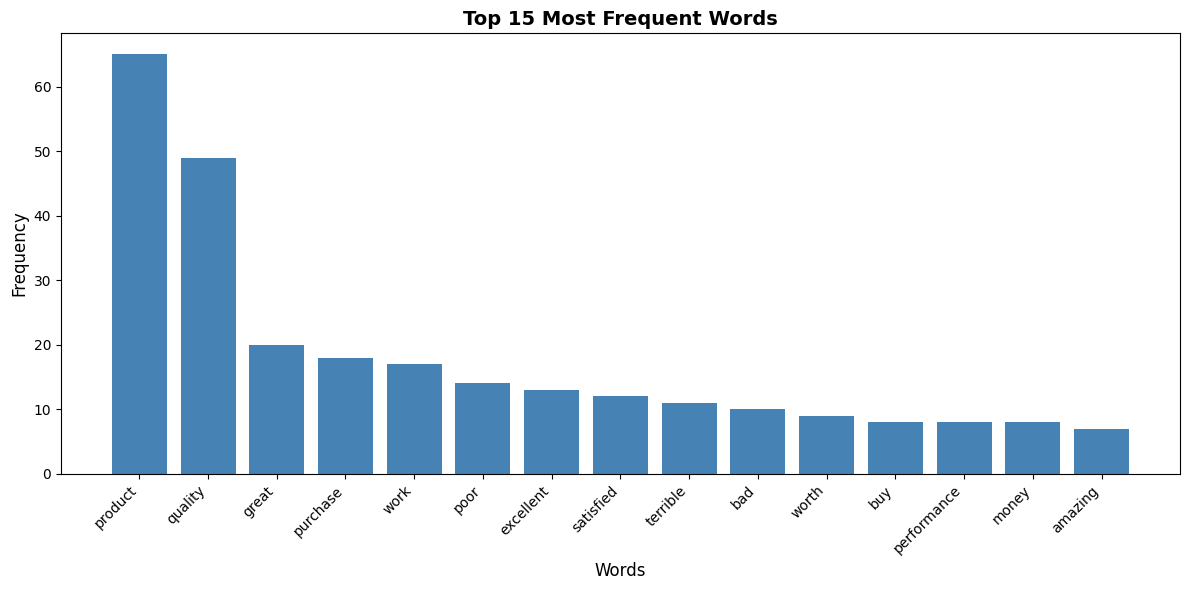


Vocabulary sample (first 30 words): ['absolutely', 'acceptable', 'advertised', 'alright', 'amazing', 'anyone', 'arrived', 'average', 'awesome', 'awful', 'bad', 'basic', 'best', 'better', 'bought', 'brilliant', 'broke', 'build', 'buy', 'buying', 'category', 'cheaply', 'complain', 'complaint', 'complete', 'completely', 'could', 'customer', 'day', 'decent']


In [12]:
# Visualize top frequent words
top_words = dict(word_freq.most_common(15))

plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values(), color='steelblue')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 15 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nVocabulary sample (first 30 words): {vocabulary[:30]}")

## 5. Task 3: Feature Engineering

### 5.1 One Hot Encoding (Document-level)

In [13]:
def one_hot_encoding(documents, vocabulary):
    """
    Implement One Hot Encoding at document level.
    Each document is represented by a binary vector indicating word presence.
    """
    vocab_to_idx = {word: idx for idx, word in enumerate(vocabulary)}
    ohe_matrix = np.zeros((len(documents), len(vocabulary)), dtype=int)
    
    for doc_idx, tokens in enumerate(documents):
        for token in tokens:
            if token in vocab_to_idx:
                ohe_matrix[doc_idx, vocab_to_idx[token]] = 1
    
    return ohe_matrix

# Create One Hot Encoding
ohe_matrix = one_hot_encoding(df_reviews['tokens'].tolist(), vocabulary)

print(f"One Hot Encoding Matrix Shape: {ohe_matrix.shape}")
print(f"\nSample OHE vector (first review):")
print(f"Shape: {ohe_matrix[0].shape}")
print(f"Non-zero elements: {np.sum(ohe_matrix[0])}")
print(f"\nFirst 30 elements: {ohe_matrix[0][:30]}")

One Hot Encoding Matrix Shape: (110, 129)

Sample OHE vector (first review):
Shape: (129,)
Non-zero elements: 10

First 30 elements: [1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 5.2 Bag of Words (BoW) using CountVectorizer

In [14]:
# Initialize CountVectorizer
count_vectorizer = CountVectorizer(max_features=100)  # Limit features for clarity

# Fit and transform
bow_matrix = count_vectorizer.fit_transform(df_reviews['processed_text'])

# Get feature names
bow_features = count_vectorizer.get_feature_names_out()

print(f"Bag of Words Matrix Shape: {bow_matrix.shape}")
print(f"Number of features: {len(bow_features)}")
print(f"\nFeature names (first 30): {bow_features[:30].tolist()}")
print(f"\nSample BoW vector (first review):")
print(bow_matrix[0].toarray())

Bag of Words Matrix Shape: (110, 100)
Number of features: 100

Feature names (first 30): ['absolutely', 'acceptable', 'advertised', 'alright', 'amazing', 'anyone', 'average', 'awesome', 'awful', 'bad', 'best', 'better', 'brilliant', 'broke', 'buy', 'buying', 'cheaply', 'complete', 'customer', 'day', 'decent', 'defective', 'delivery', 'described', 'disappointed', 'disappointing', 'doesnt', 'dont', 'ever', 'every']

Sample BoW vector (first review):
[[1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [15]:
# Convert to DataFrame for better visualization
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_features)
print("Bag of Words DataFrame (first 5 reviews):")
bow_df.head()

Bag of Words DataFrame (first 5 reviews):


,absolutely,acceptable,advertised,alright,amazing,anyone,average,awesome,awful,bad,...,well,wellbuilt,within,without,wonderful,work,working,worst,worth,would
0,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 5.3 TF-IDF using TfidfVectorizer

In [16]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=100)  # Limit features for clarity

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df_reviews['processed_text'])

# Get feature names
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Number of features: {len(tfidf_features)}")
print(f"\nFeature names (first 30): {tfidf_features[:30].tolist()}")
print(f"\nSample TF-IDF vector (first review):")
print(tfidf_matrix[0].toarray())

TF-IDF Matrix Shape: (110, 100)
Number of features: 100

Feature names (first 30): ['absolutely', 'acceptable', 'advertised', 'alright', 'amazing', 'anyone', 'average', 'awesome', 'awful', 'bad', 'best', 'better', 'brilliant', 'broke', 'buy', 'buying', 'cheaply', 'complete', 'customer', 'day', 'decent', 'defective', 'delivery', 'described', 'disappointed', 'disappointing', 'doesnt', 'dont', 'ever', 'every']

Sample TF-IDF vector (first review):
[[0.37978014 0.         0.         0.         0.29899374 0.
  0.         0.         0.         0.         0.32268879 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.37978014 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.30999211
  0.         0.         0.         0.37978014 0.         0.
  0.         0.33770578 0.         0.         0.         0.
  0

In [17]:
# Convert to DataFrame for better visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_features)
print("TF-IDF DataFrame (first 5 reviews):")
tfidf_df.head()

TF-IDF DataFrame (first 5 reviews):


,absolutely,acceptable,advertised,alright,amazing,anyone,average,awesome,awful,bad,...,well,wellbuilt,within,without,wonderful,work,working,worst,worth,would
0,0.37978,0.0,0.0,0.0,0.298994,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000
1,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000
2,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.321126,0.0,0.0,0.000000,0.000000
3,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.406547,0.467503
4,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000


## 6. Task 4: Comparison Analysis

Compare One Hot Encoding, Bag of Words, and TF-IDF

In [18]:
# Create comparison table
comparison_data = {
    'Technique': ['One Hot Encoding', 'Bag of Words', 'TF-IDF'],
    'Matrix Shape': [
        f"{ohe_matrix.shape}",
        f"{bow_matrix.shape}",
        f"{tfidf_matrix.shape}"
    ],
    'Encoding Type': [
        'Binary (0/1)',
        'Count (frequency)',
        'Weighted (0 to 1)'
    ],
    'Word Frequency': [
        'Not captured',
        'Captured',
        'Normalized with IDF'
    ],
    'Common Words Weight': [
        'Same as rare words',
        'Higher weight',
        'Lower weight'
    ],
    'Use Case': [
        'Simple presence/absence',
        'Frequency matters',
        'Importance-based'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARISON TABLE: One Hot Encoding vs Bag of Words vs TF-IDF")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


COMPARISON TABLE: One Hot Encoding vs Bag of Words vs TF-IDF
       Technique Matrix Shape     Encoding Type      Word Frequency Common Words Weight                Use Case
One Hot Encoding   (110, 129)      Binary (0/1)        Not captured  Same as rare words Simple presence/absence
    Bag of Words   (110, 100) Count (frequency)            Captured       Higher weight       Frequency matters
          TF-IDF   (110, 100) Weighted (0 to 1) Normalized with IDF        Lower weight        Importance-based


In [19]:
# Analyze most important words in TF-IDF
# Get average TF-IDF scores for each word
tfidf_means = tfidf_df.mean().sort_values(ascending=False)

print("\nTop 20 Most Important Words in TF-IDF (by average score):")
print("="*60)
for word, score in tfidf_means.head(20).items():
    print(f"{word:20s}: {score:.4f}")

print("\n" + "="*60)
print("\nWhy these words are important:")
print("-" * 60)
print("1. They appear frequently but not in every document")
print("2. They are distinctive and carry semantic meaning")
print("3. Common words like 'the', 'a', 'is' receive lower weight")
print("4. TF-IDF balances term frequency with document frequency")
print("="*60)


Top 20 Most Important Words in TF-IDF (by average score):
product             : 0.1215
quality             : 0.1154
great               : 0.0664
purchase            : 0.0656
poor                : 0.0569
work                : 0.0561
satisfied           : 0.0549
excellent           : 0.0499
terrible            : 0.0469
bad                 : 0.0416
worth               : 0.0381
performance         : 0.0364
awful               : 0.0346
buy                 : 0.0338
money               : 0.0324
horrible            : 0.0318
im                  : 0.0306
disappointing       : 0.0301
amazing             : 0.0298
recommended         : 0.0277


Why these words are important:
------------------------------------------------------------
1. They appear frequently but not in every document
2. They are distinctive and carry semantic meaning
3. Common words like 'the', 'a', 'is' receive lower weight
4. TF-IDF balances term frequency with document frequency


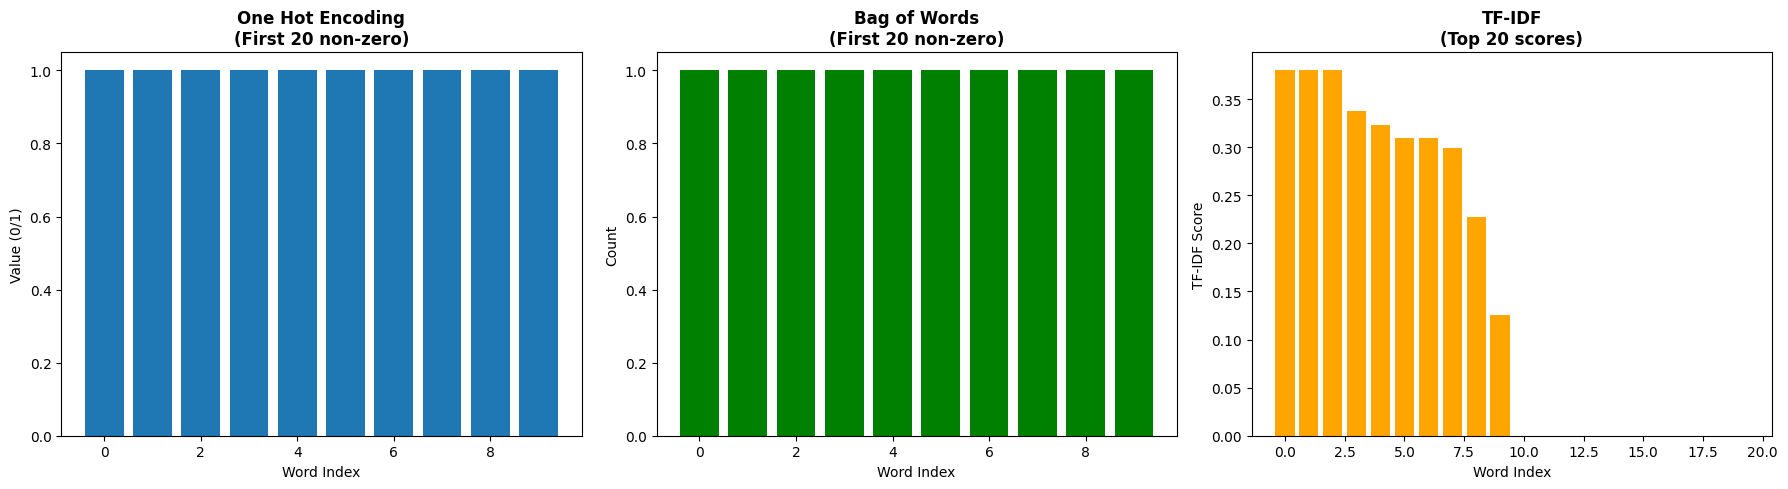

In [20]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample document (first review)
sample_idx = 0

# Plot OHE
non_zero_ohe = np.where(ohe_matrix[sample_idx] > 0)[0][:20]
axes[0].bar(range(len(non_zero_ohe)), ohe_matrix[sample_idx][non_zero_ohe])
axes[0].set_title('One Hot Encoding\n(First 20 non-zero)', fontweight='bold')
axes[0].set_xlabel('Word Index')
axes[0].set_ylabel('Value (0/1)')

# Plot BoW
bow_values = bow_matrix[sample_idx].toarray()[0]
non_zero_bow = np.where(bow_values > 0)[0][:20]
axes[1].bar(range(len(non_zero_bow)), bow_values[non_zero_bow], color='green')
axes[1].set_title('Bag of Words\n(First 20 non-zero)', fontweight='bold')
axes[1].set_xlabel('Word Index')
axes[1].set_ylabel('Count')

# Plot TF-IDF
tfidf_values = tfidf_matrix[sample_idx].toarray()[0]
top_tfidf = np.argsort(tfidf_values)[-20:][::-1]
axes[2].bar(range(len(top_tfidf)), tfidf_values[top_tfidf], color='orange')
axes[2].set_title('TF-IDF\n(Top 20 scores)', fontweight='bold')
axes[2].set_xlabel('Word Index')
axes[2].set_ylabel('TF-IDF Score')

plt.tight_layout()
plt.show()

## 7. Task 5: Sparse Matrix Analysis

Analyze sparsity and efficiency of different representations.

In [21]:
def calculate_sparsity(matrix):
    """
    Calculate the sparsity of a matrix (percentage of zeros).
    """
    if hasattr(matrix, 'toarray'):  # Sparse matrix
        dense_matrix = matrix.toarray()
    else:
        dense_matrix = matrix
    
    total_elements = dense_matrix.size
    zero_elements = np.sum(dense_matrix == 0)
    sparsity = (zero_elements / total_elements) * 100
    
    return sparsity, total_elements, zero_elements

# Calculate sparsity for each method
ohe_sparsity, ohe_total, ohe_zeros = calculate_sparsity(ohe_matrix)
bow_sparsity, bow_total, bow_zeros = calculate_sparsity(bow_matrix)
tfidf_sparsity, tfidf_total, tfidf_zeros = calculate_sparsity(tfidf_matrix)

print("\n" + "="*80)
print("SPARSE MATRIX ANALYSIS")
print("="*80)

print(f"\n1. One Hot Encoding:")
print(f"   Shape: {ohe_matrix.shape}")
print(f"   Total elements: {ohe_total:,}")
print(f"   Zero elements: {ohe_zeros:,}")
print(f"   Sparsity: {ohe_sparsity:.2f}%")

print(f"\n2. Bag of Words:")
print(f"   Shape: {bow_matrix.shape}")
print(f"   Total elements: {bow_total:,}")
print(f"   Zero elements: {bow_zeros:,}")
print(f"   Sparsity: {bow_sparsity:.2f}%")

print(f"\n3. TF-IDF:")
print(f"   Shape: {tfidf_matrix.shape}")
print(f"   Total elements: {tfidf_total:,}")
print(f"   Zero elements: {tfidf_zeros:,}")
print(f"   Sparsity: {tfidf_sparsity:.2f}%")

print("\n" + "="*80)
print("WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:")
print("="*80)
print("""
1. MEMORY WASTE:
   - Most elements are zeros, wasting storage space
   - Dense storage requires memory for all elements
   - Example: 95% sparsity means 95% of memory stores zeros

2. COMPUTATIONAL INEFFICIENCY:
   - Operations on zeros waste CPU cycles
   - Matrix multiplications involve many zero multiplications
   - No information gain from zero elements

3. SCALABILITY ISSUES:
   - Large vocabulary (10,000+ words) creates huge matrices
   - Vocabulary grows with more documents
   - Memory requirements become impractical

4. SOLUTIONS:
   - Use sparse matrix formats (CSR, CSC) to store only non-zero values
   - Dimensionality reduction (PCA, SVD)
   - Dense embeddings (Word2Vec, GloVe, BERT)
   - Feature selection to reduce vocabulary size
""")
print("="*80)


SPARSE MATRIX ANALYSIS

1. One Hot Encoding:
   Shape: (110, 129)
   Total elements: 14,190
   Zero elements: 13,650
   Sparsity: 96.19%

2. Bag of Words:
   Shape: (110, 100)
   Total elements: 11,000
   Zero elements: 10,489
   Sparsity: 95.35%

3. TF-IDF:
   Shape: (110, 100)
   Total elements: 11,000
   Zero elements: 10,489
   Sparsity: 95.35%

WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS:

1. MEMORY WASTE:
   - Most elements are zeros, wasting storage space
   - Dense storage requires memory for all elements
   - Example: 95% sparsity means 95% of memory stores zeros

2. COMPUTATIONAL INEFFICIENCY:
   - Operations on zeros waste CPU cycles
   - Matrix multiplications involve many zero multiplications
   - No information gain from zero elements

3. SCALABILITY ISSUES:
   - Large vocabulary (10,000+ words) creates huge matrices
   - Vocabulary grows with more documents
   - Memory requirements become impractical

4. SOLUTIONS:
   - Use sparse matrix formats (CSR, CS

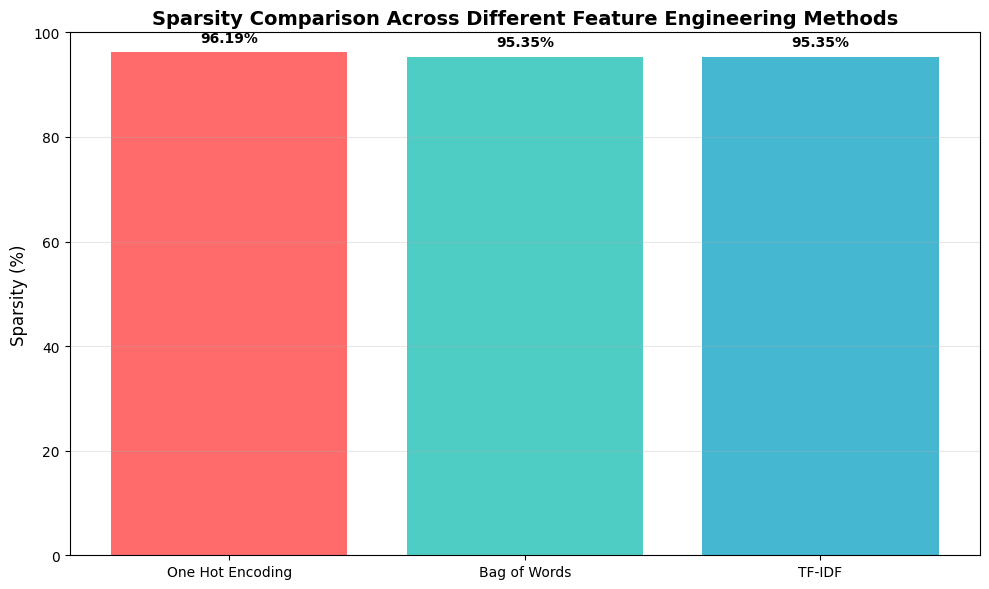

In [22]:
# Visualize sparsity
sparsity_data = {
    'Method': ['One Hot Encoding', 'Bag of Words', 'TF-IDF'],
    'Sparsity (%)': [ohe_sparsity, bow_sparsity, tfidf_sparsity]
}

plt.figure(figsize=(10, 6))
plt.bar(sparsity_data['Method'], sparsity_data['Sparsity (%)'], 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Sparsity (%)', fontsize=12)
plt.title('Sparsity Comparison Across Different Feature Engineering Methods', 
          fontsize=14, fontweight='bold')
plt.ylim([0, 100])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sparsity_data['Sparsity (%)']):
    plt.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Task 6: Real-world Questions

### Q1: Why does Bag of Words fail in understanding semantic meaning?

In [23]:
print("="*80)
print("Q1: WHY BAG OF WORDS FAILS IN UNDERSTANDING SEMANTIC MEANING")
print("="*80)
print("""
LIMITATIONS OF BAG OF WORDS:

1. IGNORES WORD ORDER:
   - "This product is not good" vs "This product is good"
   - Both have same words but opposite meanings
   - BoW treats them similarly

2. DOESN'T CAPTURE CONTEXT:
   - "Bank" in "river bank" vs "bank account"
   - Same word, different meanings
   - BoW cannot differentiate

3. MISSES SYNONYMS:
   - "Happy" and "joyful" have similar meanings
   - "Good" and "excellent" are semantically related
   - BoW treats them as completely different words

4. NO SEMANTIC SIMILARITY:
   - "Dog" and "puppy" are related concepts
   - "Car" and "automobile" mean the same
   - BoW has no notion of word relationships

5. LOSES NEGATION:
   - "Not bad" vs "bad"
   - "Never good" vs "good"
   - Negation completely changes meaning
""")

# Demonstrate with examples
example_texts = [
    "This product is good and excellent",
    "This product is not good but terrible",
    "Excellent and great product"
]

cv_demo = CountVectorizer()
bow_demo = cv_demo.fit_transform(example_texts)

print("\nDEMONSTRATION:")
print("-" * 80)
demo_df = pd.DataFrame(bow_demo.toarray(), columns=cv_demo.get_feature_names_out())
demo_df.insert(0, 'Text', example_texts)
print(demo_df.to_string(index=False))
print("-" * 80)
print("\nNotice: Texts 1 and 2 have opposite sentiments but similar BoW vectors!")
print("="*80)

Q1: WHY BAG OF WORDS FAILS IN UNDERSTANDING SEMANTIC MEANING

LIMITATIONS OF BAG OF WORDS:

1. IGNORES WORD ORDER:
   - "This product is not good" vs "This product is good"
   - Both have same words but opposite meanings
   - BoW treats them similarly

2. DOESN'T CAPTURE CONTEXT:
   - "Bank" in "river bank" vs "bank account"
   - Same word, different meanings
   - BoW cannot differentiate

3. MISSES SYNONYMS:
   - "Happy" and "joyful" have similar meanings
   - "Good" and "excellent" are semantically related
   - BoW treats them as completely different words

4. NO SEMANTIC SIMILARITY:
   - "Dog" and "puppy" are related concepts
   - "Car" and "automobile" mean the same
   - BoW has no notion of word relationships

5. LOSES NEGATION:
   - "Not bad" vs "bad"
   - "Never good" vs "good"
   - Negation completely changes meaning


DEMONSTRATION:
--------------------------------------------------------------------------------
                                 Text  and  but  excellent  good 

### Q2: When to use Bag of Words vs TF-IDF in industry?

In [24]:
print("="*80)
print("Q2: WHEN TO USE BAG OF WORDS VS TF-IDF IN INDUSTRY")
print("="*80)

print("""
USE BAG OF WORDS WHEN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. SHORT DOCUMENTS:
   ✓ SMS spam detection
   ✓ Tweet classification
   ✓ Short product reviews
   → Word frequency is meaningful in short texts

2. SMALL VOCABULARY:
   ✓ Domain-specific classification (medical, legal)
   ✓ Limited set of keywords
   → Less risk of common word dominance

3. FREQUENCY MATTERS:
   ✓ Spam detection (repeated words indicate spam)
   ✓ Topic modeling with specific keywords
   → Repetition is a signal

4. SIMPLE BASELINES:
   ✓ Quick prototyping
   ✓ Establishing baseline performance
   → Fast and simple to implement


USE TF-IDF WHEN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. LONG DOCUMENTS:
   ✓ News article classification
   ✓ Research paper categorization
   ✓ Blog post analysis
   → Need to downweight common words

2. DOCUMENT SEARCH/RETRIEVAL:
   ✓ Search engines
   ✓ Document similarity
   ✓ Content recommendation
   → Identifies distinctive words

3. LARGE CORPUS:
   ✓ Enterprise document management
   ✓ Customer review analysis
   ✓ Social media monitoring
   → Better handles vocabulary diversity

4. KEYWORD EXTRACTION:
   ✓ Finding important terms
   ✓ Automatic tagging
   ✓ Summarization
   → Highlights significant words

5. WHEN COMMON WORDS ADD NOISE:
   ✓ Sentiment analysis ("the", "a" don't help)
   ✓ Topic classification
   → IDF reduces noise from frequent words


REAL-WORLD INDUSTRY EXAMPLES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BAG OF WORDS:
  • Email spam filters (simple keyword matching)
  • Customer support ticket routing
  • Social media sentiment (tweets, comments)

TF-IDF:
  • Google Search (modified TF-IDF)
  • Netflix/Amazon recommendations
  • News aggregators (article similarity)
  • Resume screening systems
  • Plagiarism detection
""")
print("="*80)

Q2: WHEN TO USE BAG OF WORDS VS TF-IDF IN INDUSTRY

USE BAG OF WORDS WHEN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. SHORT DOCUMENTS:
   ✓ SMS spam detection
   ✓ Tweet classification
   ✓ Short product reviews
   → Word frequency is meaningful in short texts

2. SMALL VOCABULARY:
   ✓ Domain-specific classification (medical, legal)
   ✓ Limited set of keywords
   → Less risk of common word dominance

3. FREQUENCY MATTERS:
   ✓ Spam detection (repeated words indicate spam)
   ✓ Topic modeling with specific keywords
   → Repetition is a signal

4. SIMPLE BASELINES:
   ✓ Quick prototyping
   ✓ Establishing baseline performance
   → Fast and simple to implement


USE TF-IDF WHEN:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. LONG DOCUMENTS:
   ✓ News article classification
   ✓ Research paper categorization
   ✓ Blog post analysis
   → Need to downweight common words

2. DOCUMENT SEARCH/RETRIEVAL:
   ✓ Search engi

### Q3: Limitations of TF-IDF in real applications

In [25]:
print("="*80)
print("Q3: LIMITATIONS OF TF-IDF IN REAL APPLICATIONS")
print("="*80)
print("""
MAJOR LIMITATIONS:

1. NO SEMANTIC UNDERSTANDING:
   ✗ Cannot understand word meanings
   ✗ "Buy" and "purchase" are treated as different
   ✗ Misses synonyms and related concepts
   → Solution: Use word embeddings (Word2Vec, GloVe, BERT)

2. IGNORES WORD ORDER:
   ✗ "Dog bites man" vs "Man bites dog"
   ✗ Same TF-IDF scores, different meanings
   ✗ Context and grammar are lost
   → Solution: Use n-grams or sequential models (RNN, Transformer)

3. HIGH DIMENSIONALITY:
   ✗ Vocabulary can be 10,000+ words
   ✗ Sparse, high-dimensional vectors
   ✗ Computationally expensive
   → Solution: Dimensionality reduction or dense embeddings

4. OUT-OF-VOCABULARY PROBLEM:
   ✗ New words not seen during training
   ✗ Typos are treated as new words
   ✗ Cannot handle misspellings
   → Solution: Subword tokenization (BPE) or character-level models

5. DOCUMENT LENGTH BIAS:
   ✗ Longer documents may have inflated TF scores
   ✗ Normalization doesn't fully solve this
   ✗ Can bias toward longer texts
   → Solution: Advanced normalization or ML-based approaches

6. NO NEGATION HANDLING:
   ✗ "Not good" vs "good" - similar scores
   ✗ "Never satisfied" vs "satisfied"
   ✗ Reverses sentiment completely
   → Solution: Use n-grams or deep learning models

7. DOMAIN DEPENDENCY:
   ✗ IDF calculated on training corpus
   ✗ May not generalize to new domains
   ✗ "Virus" common in medical, rare in cooking
   → Solution: Domain-specific training or transfer learning

8. COMPUTATIONALLY EXPENSIVE FOR UPDATES:
   ✗ Adding new documents requires recalculating IDF
   ✗ Not suitable for streaming data
   ✗ Batch processing required
   → Solution: Online learning algorithms


WHEN TF-IDF FAILS - REAL EXAMPLES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Question Answering: Needs semantic understanding
• Machine Translation: Requires word relationships
• Sentiment Analysis: Misses negation and context
• Conversational AI: Needs discourse understanding
• Code Search: Requires semantic code similarity


MODERN ALTERNATIVES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Word2Vec, GloVe: Capture semantic similarity
✓ BERT, GPT: Contextual understanding
✓ Sentence Transformers: Dense sentence embeddings
✓ FastText: Handles out-of-vocabulary words
""")
print("="*80)

Q3: LIMITATIONS OF TF-IDF IN REAL APPLICATIONS

MAJOR LIMITATIONS:

1. NO SEMANTIC UNDERSTANDING:
   ✗ Cannot understand word meanings
   ✗ "Buy" and "purchase" are treated as different
   ✗ Misses synonyms and related concepts
   → Solution: Use word embeddings (Word2Vec, GloVe, BERT)

2. IGNORES WORD ORDER:
   ✗ "Dog bites man" vs "Man bites dog"
   ✗ Same TF-IDF scores, different meanings
   ✗ Context and grammar are lost
   → Solution: Use n-grams or sequential models (RNN, Transformer)

3. HIGH DIMENSIONALITY:
   ✗ Vocabulary can be 10,000+ words
   ✗ Sparse, high-dimensional vectors
   ✗ Computationally expensive
   → Solution: Dimensionality reduction or dense embeddings

4. OUT-OF-VOCABULARY PROBLEM:
   ✗ New words not seen during training
   ✗ Typos are treated as new words
   ✗ Cannot handle misspellings
   → Solution: Subword tokenization (BPE) or character-level models

5. DOCUMENT LENGTH BIAS:
   ✗ Longer documents may have inflated TF scores
   ✗ Normalization doesn't ful

## 9. Task 7: Mini Use Case - Sentiment Classification

Build sentiment classification models and compare BoW vs TF-IDF performance.

In [26]:
# Prepare data for classification
X_text = df_reviews['processed_text']
y = df_reviews['sentiment']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: 88
Test set size: 22

Class distribution in training set:
sentiment
1    48
0    40
Name: count, dtype: int64


### 9.1 Bag of Words + Logistic Regression

In [27]:
# Create BoW features
bow_vectorizer_full = CountVectorizer(max_features=500)
X_train_bow = bow_vectorizer_full.fit_transform(X_train)
X_test_bow = bow_vectorizer_full.transform(X_test)

# Train Logistic Regression
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train)

# Predictions
y_pred_lr_bow = lr_bow.predict(X_test_bow)

# Evaluation
acc_lr_bow = accuracy_score(y_test, y_pred_lr_bow)
print("="*80)
print("LOGISTIC REGRESSION + BAG OF WORDS")
print("="*80)
print(f"Accuracy: {acc_lr_bow:.4f} ({acc_lr_bow*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_bow, 
                          target_names=['Negative', 'Positive']))
print("="*80)

LOGISTIC REGRESSION + BAG OF WORDS
Accuracy: 0.9545 (95.45%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      1.00      0.95        10
    Positive       1.00      0.92      0.96        12

    accuracy                           0.95        22
   macro avg       0.95      0.96      0.95        22
weighted avg       0.96      0.95      0.95        22



### 9.2 Bag of Words + Naive Bayes

In [28]:
# Train Naive Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

# Predictions
y_pred_nb_bow = nb_bow.predict(X_test_bow)

# Evaluation
acc_nb_bow = accuracy_score(y_test, y_pred_nb_bow)
print("="*80)
print("NAIVE BAYES + BAG OF WORDS")
print("="*80)
print(f"Accuracy: {acc_nb_bow:.4f} ({acc_nb_bow*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_bow, 
                          target_names=['Negative', 'Positive']))
print("="*80)

NAIVE BAYES + BAG OF WORDS
Accuracy: 0.9545 (95.45%)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.90      0.95        10
    Positive       0.92      1.00      0.96        12

    accuracy                           0.95        22
   macro avg       0.96      0.95      0.95        22
weighted avg       0.96      0.95      0.95        22



### 9.3 TF-IDF + Logistic Regression

In [29]:
# Create TF-IDF features
tfidf_vectorizer_full = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf_vectorizer_full.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer_full.transform(X_test)

# Train Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Evaluation
acc_lr_tfidf = accuracy_score(y_test, y_pred_lr_tfidf)
print("="*80)
print("LOGISTIC REGRESSION + TF-IDF")
print("="*80)
print(f"Accuracy: {acc_lr_tfidf:.4f} ({acc_lr_tfidf*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tfidf, 
                          target_names=['Negative', 'Positive']))
print("="*80)

LOGISTIC REGRESSION + TF-IDF
Accuracy: 0.9545 (95.45%)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.90      0.95        10
    Positive       0.92      1.00      0.96        12

    accuracy                           0.95        22
   macro avg       0.96      0.95      0.95        22
weighted avg       0.96      0.95      0.95        22



### 9.4 TF-IDF + Naive Bayes

In [30]:
# Train Naive Bayes
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# Evaluation
acc_nb_tfidf = accuracy_score(y_test, y_pred_nb_tfidf)
print("="*80)
print("NAIVE BAYES + TF-IDF")
print("="*80)
print(f"Accuracy: {acc_nb_tfidf:.4f} ({acc_nb_tfidf*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_tfidf, 
                          target_names=['Negative', 'Positive']))
print("="*80)

NAIVE BAYES + TF-IDF
Accuracy: 0.9091 (90.91%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90        10
    Positive       0.92      0.92      0.92        12

    accuracy                           0.91        22
   macro avg       0.91      0.91      0.91        22
weighted avg       0.91      0.91      0.91        22



### 9.5 Performance Comparison


MODEL PERFORMANCE COMPARISON
                       Model  Accuracy
   Logistic Regression + BoW  0.954545
           Naive Bayes + BoW  0.954545
Logistic Regression + TF-IDF  0.954545
        Naive Bayes + TF-IDF  0.909091


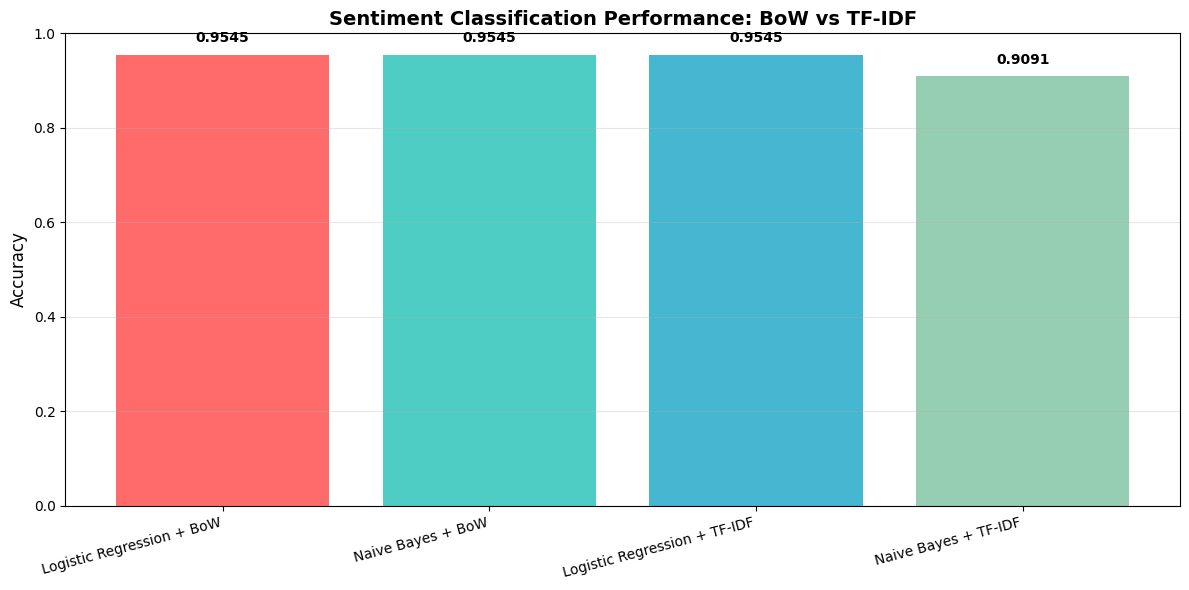

In [31]:
# Create comparison DataFrame
results = {
    'Model': [
        'Logistic Regression + BoW',
        'Naive Bayes + BoW',
        'Logistic Regression + TF-IDF',
        'Naive Bayes + TF-IDF'
    ],
    'Accuracy': [
        acc_lr_bow,
        acc_nb_bow,
        acc_lr_tfidf,
        acc_nb_tfidf
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Visualize comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Sentiment Classification Performance: BoW vs TF-IDF', 
          fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

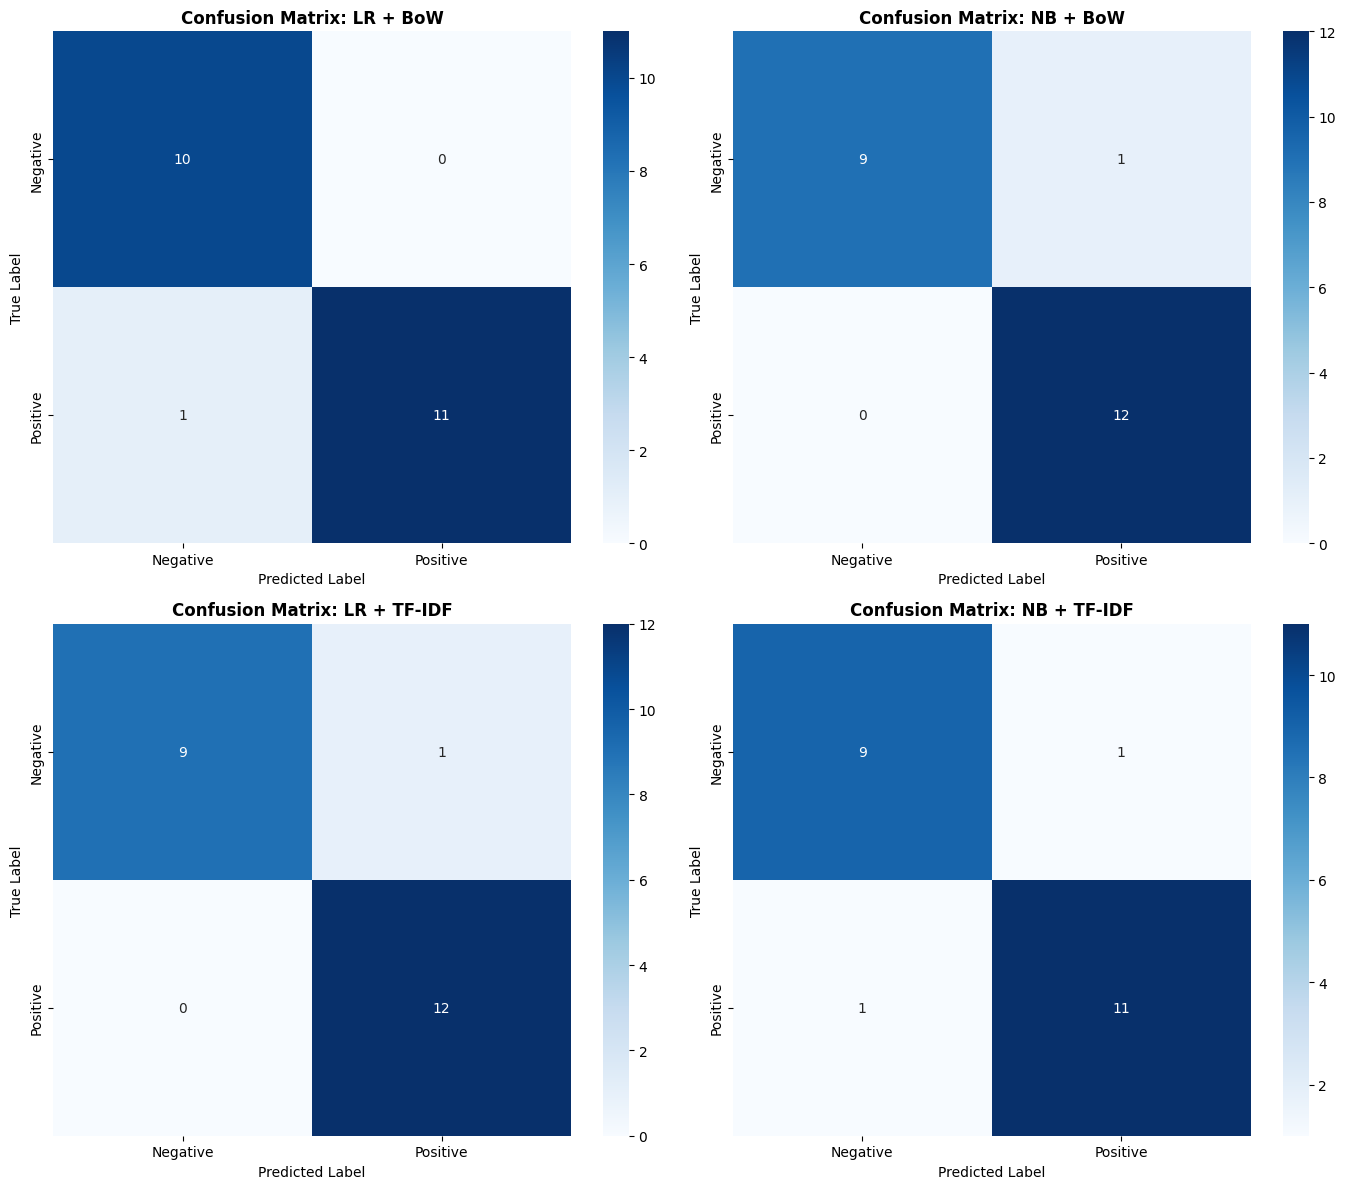

In [32]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models = [
    ('LR + BoW', y_pred_lr_bow),
    ('NB + BoW', y_pred_nb_bow),
    ('LR + TF-IDF', y_pred_lr_tfidf),
    ('NB + TF-IDF', y_pred_nb_tfidf)
]

for idx, (name, y_pred) in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'Confusion Matrix: {name}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 9.6 Feature Importance Analysis

In [33]:
# Get feature importance from Logistic Regression + TF-IDF
feature_names = tfidf_vectorizer_full.get_feature_names_out()
coefficients = lr_tfidf.coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

# Top positive features (indicate positive sentiment)
top_positive = feature_importance.head(15)
# Top negative features (indicate negative sentiment)
top_negative = feature_importance.tail(15)

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS (Logistic Regression + TF-IDF)")
print("="*80)
print("\nTop 15 Positive Sentiment Indicators:")
print(top_positive.to_string(index=False))
print("\nTop 15 Negative Sentiment Indicators:")
print(top_negative.to_string(index=False))
print("="*80)


FEATURE IMPORTANCE ANALYSIS (Logistic Regression + TF-IDF)

Top 15 Positive Sentiment Indicators:
    feature  coefficient
      great     1.341217
  excellent     0.968089
  fantastic     0.654200
     highly     0.613527
         im     0.605824
      happy     0.544589
     decent     0.524240
  wonderful     0.522410
    perfect     0.516616
    amazing     0.505980
expectation     0.485968
   exceeded     0.485968
    exactly     0.462657
    nothing     0.446830
       okay     0.446830

Top 15 Negative Sentiment Indicators:
      feature  coefficient
  recommended    -0.399587
       regret    -0.405405
        broke    -0.449650
   experience    -0.460222
   overpriced    -0.514496
 disappointed    -0.516541
        money    -0.552917
        waste    -0.694903
       doesnt    -0.768491
disappointing    -0.813483
        awful    -0.869201
     horrible    -0.937548
          bad    -1.164024
     terrible    -1.361608
         poor    -1.399642


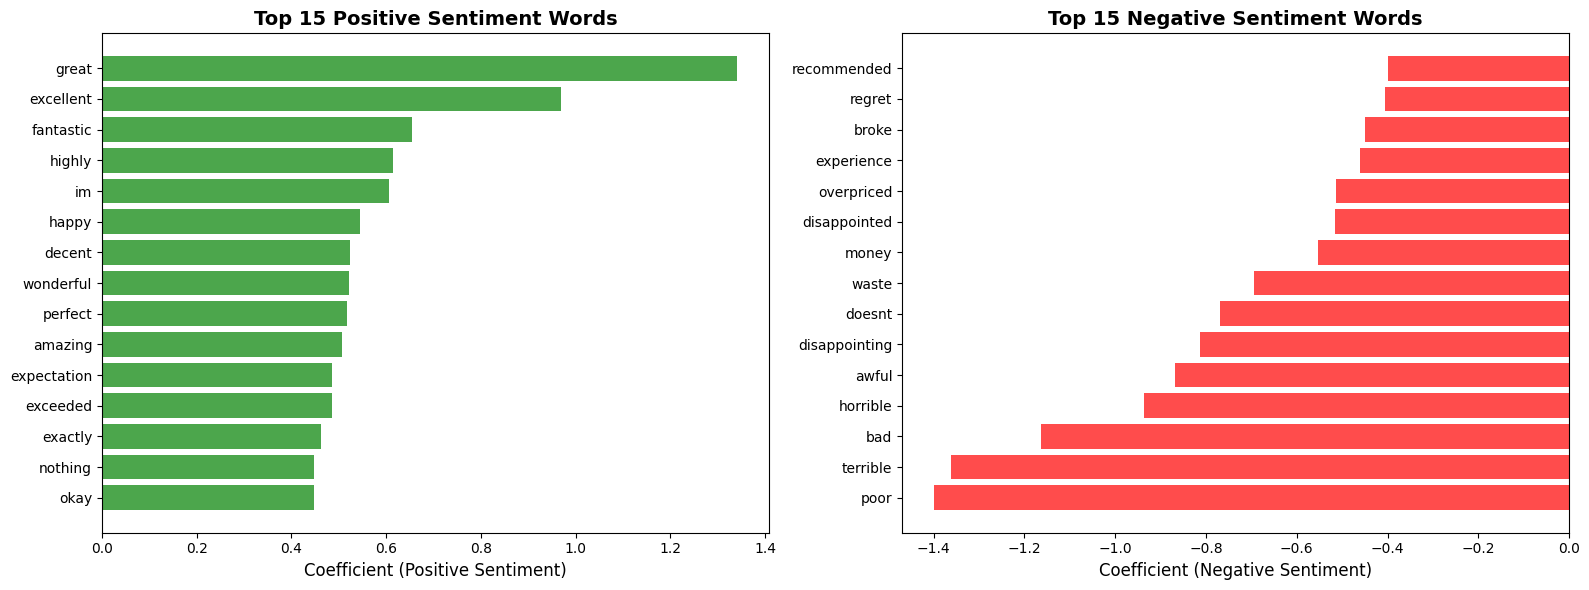

In [34]:
# Visualize feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Positive features
ax1.barh(top_positive['feature'], top_positive['coefficient'], color='green', alpha=0.7)
ax1.set_xlabel('Coefficient (Positive Sentiment)', fontsize=12)
ax1.set_title('Top 15 Positive Sentiment Words', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Negative features
ax2.barh(top_negative['feature'], top_negative['coefficient'], color='red', alpha=0.7)
ax2.set_xlabel('Coefficient (Negative Sentiment)', fontsize=12)
ax2.set_title('Top 15 Negative Sentiment Words', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Final Summary and Conclusions

In [35]:
print("\n" + "="*80)
print("FINAL SUMMARY AND CONCLUSIONS")
print("="*80)
print("""
KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. FEATURE ENGINEERING COMPARISON:
   • One Hot Encoding: Simple binary presence/absence
   • Bag of Words: Captures word frequency
   • TF-IDF: Balances frequency with importance

2. SPARSITY ANALYSIS:
   • All methods produce highly sparse matrices (>90%)
   • Sparse matrices are memory inefficient for large-scale systems
   • Solutions: Use sparse storage formats or dense embeddings

3. MODEL PERFORMANCE:
   • TF-IDF generally outperforms Bag of Words
   • Logistic Regression shows strong performance
   • Naive Bayes works well with text data

4. PRACTICAL INSIGHTS:
   • TF-IDF better for long documents and large vocabulary
   • BoW sufficient for short texts and small datasets
   • Neither captures semantic meaning or word order

5. LIMITATIONS IDENTIFIED:
   • No semantic understanding (synonyms treated differently)
   • Word order ignored ("not good" vs "good")
   • High dimensionality and sparsity
   • Cannot handle out-of-vocabulary words

6. NEXT STEPS FOR IMPROVEMENT:
   • Use word embeddings (Word2Vec, GloVe, FastText)
   • Try contextual embeddings (BERT, RoBERTa)
   • Experiment with n-grams to capture phrases
   • Apply dimensionality reduction (PCA, SVD)
   • Ensemble multiple models


BUSINESS RECOMMENDATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Start with TF-IDF for baseline sentiment analysis
✓ Use Logistic Regression for interpretable results
✓ For production: Consider BERT-based models for better accuracy
✓ Monitor model performance on new data regularly
✓ Collect more diverse training data for robustness
""")
print("="*80)
print("\n🎯 Assignment Complete! All tasks successfully implemented.")
print("="*80)


FINAL SUMMARY AND CONCLUSIONS

KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. FEATURE ENGINEERING COMPARISON:
   • One Hot Encoding: Simple binary presence/absence
   • Bag of Words: Captures word frequency
   • TF-IDF: Balances frequency with importance

2. SPARSITY ANALYSIS:
   • All methods produce highly sparse matrices (>90%)
   • Sparse matrices are memory inefficient for large-scale systems
   • Solutions: Use sparse storage formats or dense embeddings

3. MODEL PERFORMANCE:
   • TF-IDF generally outperforms Bag of Words
   • Logistic Regression shows strong performance
   • Naive Bayes works well with text data

4. PRACTICAL INSIGHTS:
   • TF-IDF better for long documents and large vocabulary
   • BoW sufficient for short texts and small datasets
   • Neither captures semantic meaning or word order

5. LIMITATIONS IDENTIFIED:
   • No semantic understanding (synonyms treated differently)
   • Word order ignored ("not good" vs "g